# Install & Import Library

In [ ]:
!pip install optuna gensim nltk tensorflow scikit-learn

import numpy as np
import pandas as pd
import nltk
from nltk.tokenize import word_tokenize
nltk.download('punkt_tab')

from gensim.models import KeyedVectors
import optuna
import tensorflow as tf
from tensorflow.keras.layers import Input, Embedding, Bidirectional, GRU, Dense, Dropout
from tensorflow.keras.models import Model

from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.metrics import classification_report, confusion_matrix, f1_score
import seaborn as sns
import matplotlib.pyplot as plt


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 404.7/404.7 kB 8.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 48.9 MB/s eta 0:00:00


[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


# Load Dataset + Split Train/Val/Test :

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

file_path = "/content/drive/MyDrive/NLP_Project/combined_dataset.csv"
df = pd.read_csv(file_path)

X = df["clean_text"].astype(str)
y = df["encoded_label"]

# Step 1: Test 20%
X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

# Step 2: Validation 10% dari total
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.125, stratify=y_temp, random_state=42
)

print(len(X_train), len(X_val), len(X_test))


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
1445 207 414


# Load FastText Embedding

In [ ]:
fasttext_path = "/content/drive/MyDrive/NLP_Project/cc.id.300.vec"

w2v = KeyedVectors.load_word2vec_format(fasttext_path, binary=False)

embedding_dim = 300


# Build Vocabulary (Menggunakan nltk.word_tokenize)

In [ ]:
def build_vocab(texts):
    vocab = {}
    idx = 1  # 0 untuk PAD

    for txt in texts:
        for tok in word_tokenize(txt):
            if tok not in vocab:
                vocab[tok] = idx
                idx += 1
    return vocab

vocab = build_vocab(X_train)
vocab_size = len(vocab) + 1


# Create embedding matrix:

In [ ]:
embedding_matrix = np.zeros((vocab_size, embedding_dim))

for word, idx in vocab.items():
    if word in w2v:
        embedding_matrix[idx] = w2v[word]
    else:
        embedding_matrix[idx] = np.random.normal(size=(embedding_dim,))


# Convert Text → Sequences :

In [ ]:
def text_to_sequence(text, vocab, max_len=40):
    tokens = word_tokenize(text)
    seq = [vocab.get(tok, 0) for tok in tokens][:max_len]
    seq += [0] * (max_len - len(seq))
    return seq

def convert_dataset(X):
    return np.array([text_to_sequence(t, vocab) for t in X])

X_train_vec = convert_dataset(X_train)
X_val_vec   = convert_dataset(X_val)
X_test_vec  = convert_dataset(X_test)


# Build Bi-GRU Model :

In [ ]:
def build_model(h_units, dropout_rate, lr):

    inp = Input(shape=(40,))
    emb = Embedding(
        input_dim=vocab_size,
        output_dim=embedding_dim,
        weights=[embedding_matrix],
        trainable=False
    )(inp)

    x = Bidirectional(GRU(h_units, return_sequences=False))(emb)
    x = Dropout(dropout_rate)(x)

    x = Dense(64, activation="relu")(x)
    x = Dropout(dropout_rate)(x)

    out = Dense(1, activation="sigmoid")(x)

    model = Model(inp, out)
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=lr),
        loss="binary_crossentropy",
        metrics=["accuracy"]
    )

    return model


# Optuna Objective No KFold

In [ ]:
def objective(trial):

    h_units       = trial.suggest_int("h_units", 32, 128)
    dropout_rate  = trial.suggest_float("dropout", 0.1, 0.5)
    lr            = trial.suggest_float("lr", 1e-4, 5e-3, log=True)

    model = build_model(h_units, dropout_rate, lr)

    model.fit(
        X_train_vec, y_train,
        validation_data=(X_val_vec, y_val),
        epochs=5,
        batch_size=32,
        verbose=0
    )

    preds = (model.predict(X_val_vec) > 0.5).astype("int32")
    f1 = f1_score(y_val, preds)

    return f1


# Run optimization
study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=50)

best = study.best_params
best


[I 2025-11-27 03:25:03,791] A new study created in memory with name: no-name-6a4d9457-0535-4583-892f-751edf82f37b


7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step


[I 2025-11-27 03:25:16,053] Trial 0 finished with value: 0.8359788359788359 and parameters: {'h_units': 40, 'dropout': 0.1693679390450218, 'lr': 0.002621107517825746}. Best is trial 0 with value: 0.8359788359788359.


7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step


[I 2025-11-27 03:25:21,295] Trial 1 finished with value: 0.8449197860962567 and parameters: {'h_units': 39, 'dropout': 0.17173139738068371, 'lr': 0.0010551756296671294}. Best is trial 1 with value: 0.8449197860962567.


...

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step


[I 2025-11-27 03:29:38,839] Trial 48 finished with value: 0.865979381443299 and parameters: {'h_units': 110, 'dropout': 0.18275819470642113, 'lr': 0.0032399536730478304}. Best is trial 29 with value: 0.8756218905472637.


7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step


[I 2025-11-27 03:29:45,352] Trial 49 finished with value: 0.8631578947368421 and parameters: {'h_units': 110, 'dropout': 0.18344377725002223, 'lr': 0.0030012119217938562}. Best is trial 29 with value: 0.8756218905472637.


{'h_units': 120, 'dropout': 0.15085591934604586, 'lr': 0.0026637127032438307}

# Final Training on Train + Val

In [ ]:
best_h    = best["h_units"]
best_drop = best["dropout"]
best_lr   = best["lr"]

final_model = build_model(best_h, best_drop, best_lr)

X_final = np.concatenate([X_train_vec, X_val_vec])
y_final = np.concatenate([y_train, y_val])

final_model.fit(
    X_final, y_final,
    epochs=10,
    batch_size=32,
    verbose=1
)


Epoch 1/10
52/52 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - accuracy: 0.6447 - loss: 0.6220
Epoch 2/10
52/52 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.7982 - loss: 0.4092
Epoch 3/10
52/52 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.8952 - loss: 0.2542
Epoch 4/10
52/52 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9116 - loss: 0.2115
Epoch 5/10
52/52 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.9313 - loss: 0.1696
Epoch 6/10
52/52 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9476 - loss: 0.1433
Epoch 7/10
52/52 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9476 - loss: 0.1443
Epoch 8/10
52/52 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9696 - loss: 0.0998
Epoch 9/10
52/52 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9647 - loss: 0.1006
Epoch 10/10
52/52 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9775 - loss: 0.0644


# Evaluation on Test Set

13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
              precision    recall  f1-score   support

         0.0     0.8313    0.9079    0.8679       228
         1.0     0.8727    0.7742    0.8205       186

    accuracy                         0.8478       414
   macro avg     0.8520    0.8410    0.8442       414
weighted avg     0.8499    0.8478    0.8466       414



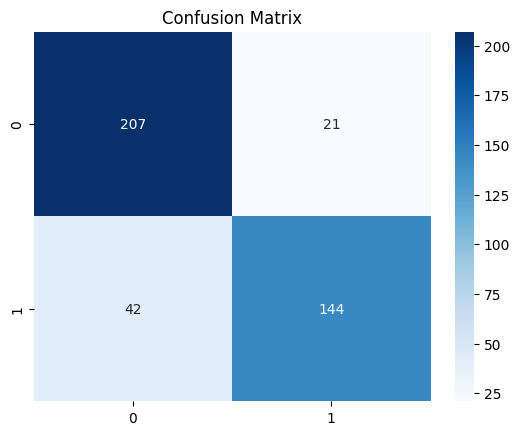

Macro F1: 0.8442186744073537


In [ ]:
y_pred = (final_model.predict(X_test_vec) > 0.5).astype("int32")

print(classification_report(y_test, y_pred, digits=4))

cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix")
plt.show()

print("Macro F1:", f1_score(y_test, y_pred, average="macro"))



# Save Experiment Configuration

In [ ]:
import json
from pprint import pprint

experiment_config = {
    "tokenizer": "nltk.word_tokenize",
    "embedding": "fasttext",
    "model": "Bi-GRU",
    "use_kfold": True,
    "kfold_splits": 5,
    "best_params": best,
    "embedding_dim": embedding_dim
}

print("\nExperiment Configuration:")
pprint(experiment_config)

print("\nJSON Format:")
print(json.dumps(experiment_config, indent=4))



Experiment Configuration:
{'best_params': {'dropout': 0.15085591934604586,
                 'h_units': 120,
                 'lr': 0.0026637127032438307},
 'embedding': 'fasttext',
 'embedding_dim': 300,
 'kfold_splits': 5,
 'model': 'Bi-GRU',
 'tokenizer': 'nltk.word_tokenize',
 'use_kfold': True}

JSON Format:
{
    "tokenizer": "nltk.word_tokenize",
    "embedding": "fasttext",
    "model": "Bi-GRU",
    "use_kfold": true,
    "kfold_splits": 5,
    "best_params": {
        "h_units": 120,
        "dropout": 0.15085591934604586,
        "lr": 0.0026637127032438307
    },
    "embedding_dim": 300
}
